# 0.1 · The real credit data

*0. General · notebook 0.1 of the story.* ← (start of the story) · [0.2 · the PD prior](<0.2_prior_visualisation_pd.ipynb>) →

**What every model in this project is scored on.** Twenty-one real credit datasets — 14 PD (a
default flag) and 7 LGD (the share of the exposure lost, on [0, 1]). They are the measuring
instrument: never training data, never a prior. This notebook fixes what a credit prior has to
reproduce, in the order a reader needs it:

- **A — the targets**: how rare default is, what an LGD target looks like, and which boundary its
  mass sits on;
- **B — the tables**: their size, their feature types, their missing values and how strongly their
  features depend on each other;
- **C — whether the scores can be trusted**: a screen for columns that give the answer away.

Each experiment splits these datasets once, in its config: a prior is **chosen** on the
*development* datasets and **reported** on the untouched *holdout* ones. For Experiment 1 the PD
development set is `gmsc`, `lendingclub`, `taiwan_creditcard`, `german`, `myhom` and the LGD one
`lgd_lendingclub`, `base_model`, `heloc`; the remaining nine PD and four LGD datasets are holdout.

Every table is read from the processed cache through `src.data.pipeline` — exactly what the
evaluation reads. A dataset not yet processed is processed on first access, once.

## Grounding in the literature

Each property this notebook measures is one `tfm-library` names as unmet by the default TFM prior.
**Imbalance:** below roughly a 10 % base rate a default-threshold classifier collapses to predicting
"no default" for everyone on real credit data (`papers/2026/05_Tanna_DataPresentation` §5.1), and
O'Prior, the one prior paper that evaluates realism, lightly filters away the most imbalanced tasks
rather than generating them (`papers/2026/05_Bouadi_ShapingThePrior`). **Bounded targets:** the same
paper never exercises its regression branch, so a [0, 1] target with point masses is untested ground.
**Missing values:** TabICLv2 mean-imputes them at inference (`repositories/TabICL.txt`
`TransformToNumerical`), and the gap by which gradient-boosted trees beat TFMs grows with the share of
missing values (ρ = +0.29) and with high-cardinality categoricals (ρ = +0.47;
`papers/2026/06_Purucker_BeyondIID` Table E.3). Pin `e5ce016`.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib
ROOT = pathlib.Path.cwd()
# Walk up to the repository root — the notebook may be opened from its chapter folder, from
# notebooks/, or from the root — then work FROM the root, so relative paths (config/...) resolve
# exactly as under `python -m src.utils.run_notebooks`.
while not (ROOT / "src" / "visualize").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from src.visualize import data_plots, figures, style, summaries, literature

style.apply()
pd.set_option("display.width", 220, "display.max_columns", 60, "display.max_rows", 60)

# Clears THIS notebook's figure folder — and no other — before anything is drawn.
FIGS = figures.FigureSaver("0.1_data_exploration")

## Loading the datasets

A dataset that cannot be read is skipped with a message, so one broken raw file does not stop the
other twenty from being examined.

In [2]:
lgd = data_plots.load_all("lgd")
pd_ = data_plots.load_all("pd")
both = {"lgd": lgd, "pd": pd_}
print(f"\nloaded {len(lgd)} LGD and {len(pd_)} PD datasets")


loaded 7 LGD and 14 PD datasets


## A · What are we predicting?

The two targets as they really are — the things the credit prior's target mechanisms are built to
match.

### A1 · PD — how rare is default?

**What it shows.** The default rate of every PD dataset, sorted, with Tanna 2026's 10 % collapse threshold as a dashed line. The table above it gives each dataset's size, feature counts and the rate as odds.

**Why it matters.** The base rate is the first thing a PD model has to adapt to, and a prior decides which base rates the model ever sees. Below about 10 % a default-threshold classifier on real credit data predicts no defaults at all, so books in that regime are where a well-calibrated probability is worth most — and why the results notebooks never report accuracy alone.

**What it says.** Rates run from 6.7 % (`gmsc`, 1 default per 14 loans that did not default) to 40 % (`myhom`), median 22.4 %. Three books sit below the 10 % line: `gmsc`, `home_credit` (8.1 %) and `loan_default` (9.3 %). TabICL's own prior spreads its tasks' base rates over the whole of [0, 1] around a median of 50 % (notebook 0.2, A2), so every real book lies in its lower half.

In [3]:
data_plots.summary_table(pd_, 'pd')

,dataset,rows,features,categorical,% categorical,missing %,base rate,imbalance 1:n,n positive
0,0006.hackerearth,532428,37,2,5.4,6.53,0.2363,3.2,125827
1,0012.home_credit,307511,120,16,13.3,22.73,0.0807,11.4,24825
2,0003.vehicle_loan,233154,33,1,3.0,0.00,0.2171,3.6,50611
3,0014.algorithmwatch,158700,2986,0,0.0,0.00,0.3781,1.6,60003
4,0001.gmsc,150000,10,0,0.0,2.24,0.0668,14.0,10026
5,0011.loan_default,105471,759,0,0.0,0.98,0.0928,9.8,9783
6,0009.bank_status,100000,16,0,0.0,6.09,0.2264,3.4,22639
7,0007.cobranded,80000,47,0,0.0,18.84,0.2462,3.1,19697
8,0002.taiwan_creditcard,30000,23,0,0.0,0.00,0.2212,3.5,6636
9,0004.lendingclub,9578,13,1,7.7,0.00,0.1601,5.2,1533


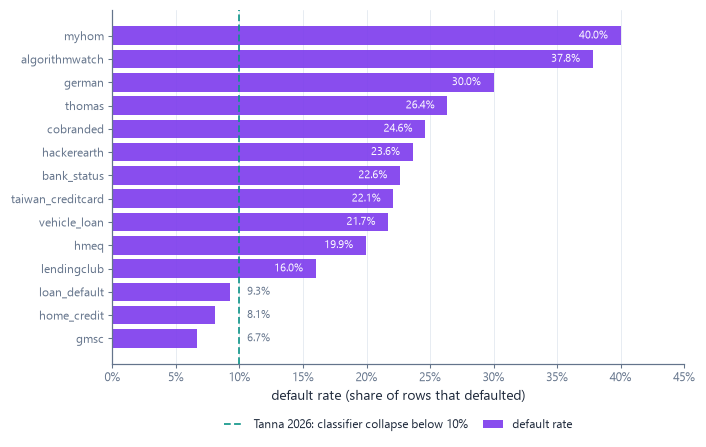

In [4]:
FIGS.save(data_plots.plot_pd_base_rates(pd_), "pd_base_rates",
    caption="Default rate per PD dataset as horizontal bars, sorted by rate, with the rate written on each bar; the dashed vertical line marks the 10% base rate below which a default-threshold classifier collapses to the majority class (Tanna 2026).");

### A2 · LGD — what does the target look like?

**What it shows.** One histogram per LGD dataset: the share of rows in each of 40 bins on [0, 1]. A dashed line marks an exact minimum or maximum that holds more than 1 % of the rows, and each panel's title gives the share of rows at exactly 0 or 1.

**Why it matters.** Rows at exactly 0 (the loan recovered in full) and exactly 1 (a total loss) are point masses, not the ends of a smooth curve. A model that only predicts smooth interior values can get the average loss right while being wrong about every individual loan, so these atoms are what the LGD prior exists to teach.

**What it says.** All seven targets lie inside [0, 1], and no two look alike. `heloc` is almost all atoms (73 % of rows at 0 or 1); `lgd_lendingclub` has almost none (1.8 %) and a hump towards high losses; `axa`, `base_model` and `base_modelisation` pile up near 0 with a smaller spike at 1; `lgd_freddie` is flat between atoms at both ends; `loss2` is humped at low losses.

In [5]:
data_plots.summary_table(lgd, 'lgd')

,dataset,rows,features,categorical,% categorical,missing %,mass at 0,mass at 1,boundary mass,mean,"in [0,1]"
0,0001.heloc,58862,9,0,0.0,3.47,0.2156,0.5147,0.7302,0.7069,True
1,0006.lgd_freddie,16002,20,8,40.0,1.17,0.1142,0.0807,0.1949,0.4588,True
2,0007.lgd_lendingclub,5627,17,7,41.2,0.07,0.0148,0.0032,0.0179,0.5905,True
3,0002.loss2,4637,52,23,44.2,2.70,0.0362,0.0371,0.0733,0.3920,True
4,0003.axa,2545,2,0,0.0,0.00,0.2861,0.0562,0.3422,0.2281,True
5,0004.base_model,762,202,88,43.6,8.79,0.1050,0.1194,0.2244,0.3234,True
6,0005.base_modelisation,594,256,77,30.1,0.70,0.1162,0.1599,0.2761,0.3301,True


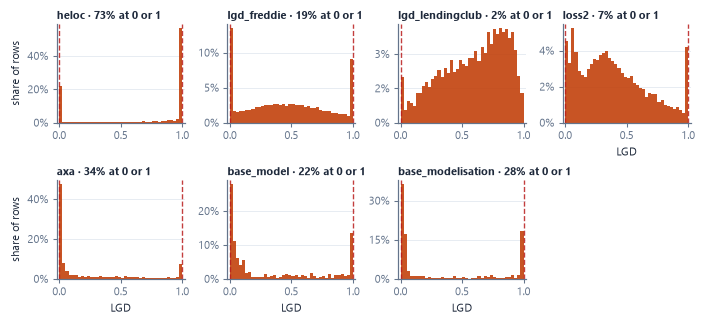

In [6]:
FIGS.save(data_plots.plot_lgd_targets(lgd), "lgd_targets",
    caption="Histograms of the LGD target for each of the seven LGD datasets, share of rows per bin, 40 bins on [0, 1], ordered by sample size; dashed vertical lines mark exact minimum or maximum values holding more than 1% of rows, and panel titles give the share of rows at exactly 0 or 1.");

### A3 · LGD — which boundary does the mass sit on?

**What it shows.** For each LGD dataset, the share of rows at exactly 0 and at exactly 1, stacked into one bar and sorted by the total.

**Why it matters.** The total hides the direction. A book where most defaults recover in full and one where most are total losses can share a total, but they are different problems — so a prior must generate the two atoms separately and over a range.

**What it says.** The total runs from 1.8 % (`lgd_lendingclub`) to 73.0 % (`heloc`), a factor of about 40, so no single boundary mass fits: Experiment 1's credit prior draws the share at 0 and the share at 1 independently from [0.02, 0.30] (mild) or [0.15, 0.60] (aggressive). The direction differs too: `heloc` is loss-heavy (21.6 % at 0, 51.5 % at 1) while `axa` is recovery-heavy (28.6 % at 0, 5.6 % at 1).

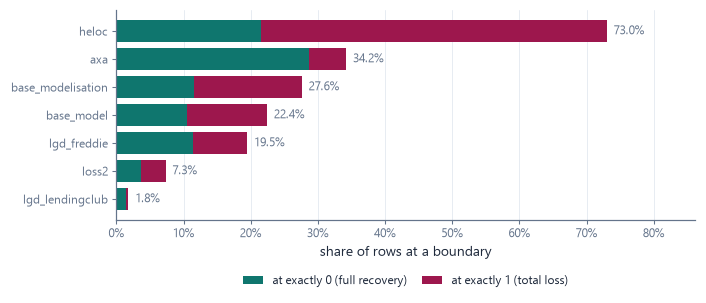

In [7]:
FIGS.save(data_plots.plot_boundary_mass_ranking(lgd), "boundary_mass_ranking",
    caption="Share of rows lying exactly at 0 (full recovery) and exactly at 1 (total loss) per LGD dataset, as stacked horizontal bars ordered by the total, which is written at the end of each bar.");

## B · What does a model read the target from?

The tables themselves — the ranges a prior's tables should cover.

### B1 · How big are the tables?

**What it shows.** Rows against features for all 21 datasets, both on logarithmic axes, each point named. The dotted lines mark the table the prior generates: exactly 1,024 rows and at most 100 features.

**Why it matters.** A model trained only on 1,024-row, ≤100-feature tables is evaluated on real tables far outside that range: during training the development monitor gives it 512 context rows and scores up to 2,000.

**What it says.** Real tables are much longer than the prior's — from 594 rows (`base_modelisation`) to 532,428 (`hackerearth`); only `base_modelisation` (594), `base_model` (762) and `german` (1,000) have fewer than 1,024. Five are wider than 100 features: `algorithmwatch` (2,986), `loan_default` (759), `base_modelisation` (256), `base_model` (202) and `home_credit` (120).

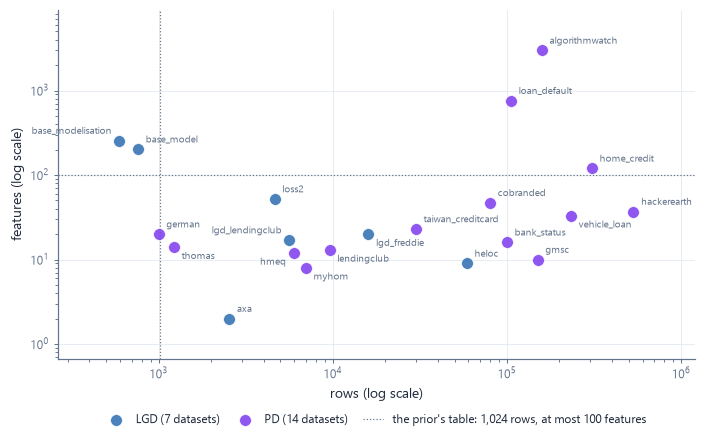

In [8]:
FIGS.save(data_plots.plot_shapes(both), "shapes",
    caption="Number of rows against number of features for all 21 evaluation datasets on logarithmic axes, one labelled point per dataset coloured by task; dotted lines mark 1,024 rows and 100 features, the size of a generated table.");

### B2 · Which features are categorical?

**What it shows.** The share of each dataset's columns that are categorical, sorted, coloured by task.

**Why it matters.** TabICLv2 encodes categorical columns its own way, and the margin by which gradient-boosted trees beat TFMs grows with high-cardinality categoricals (ρ = +0.47, `papers/2026/06_Purucker_BeyondIID` Table E.3) — which is why our credit prior allows categories with up to 500 levels against the original's 200.

**What it says.** The two tasks differ: the median LGD dataset is 40 % categorical, the median PD dataset 4 %. `german` is the most categorical (65 %); eight datasets have no categorical column at all.

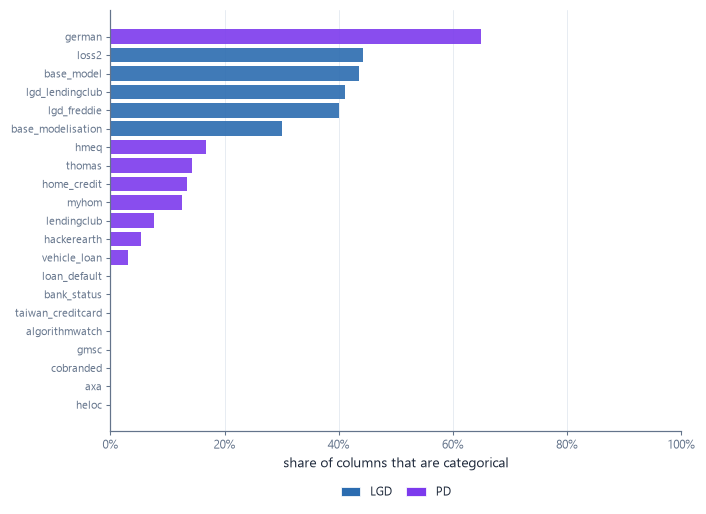

In [9]:
FIGS.save(data_plots.plot_type_mix(both), "type_mix",
    caption="Share of columns that are categorical per dataset, all 21 evaluation datasets, as horizontal bars sorted by share and coloured by task.");

### B3 · How much is missing?

**What it shows.** The share of cells that are missing in each dataset after preprocessing — what a model actually receives.

**Why it matters.** In credit a missing field can itself be a risk signal (a thin credit file), and our prior injects missing values that depend on the outcome (0.2 B3, 0.3 B3). This figure says whether the real books let such a signal through.

**What it says.** Seven of the 21 datasets have no missing values left: most were imputed before we received them. The rest range up to 22.7 % (`home_credit`) and 18.8 % (`cobranded`). These numbers measure the upstream pipelines, not the credit domain, so the prior's missing-value rates are not tuned to them.

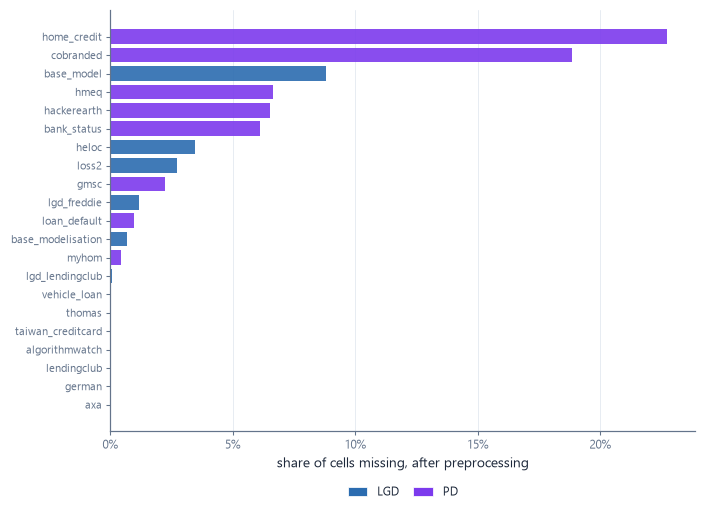

In [10]:
FIGS.save(data_plots.plot_missingness(both), "missingness",
    caption="Share of cells that are missing per dataset after preprocessing, all 21 evaluation datasets, as horizontal bars sorted by share and coloured by task.");

### B4 · How strongly do the features depend on each other?

**What it shows.** The Pearson correlation between every pair of features, one matrix per dataset (a random 5,000-row sample, constant columns removed), ordered from the most to the least dependent; under each panel, the number of features and the mean absolute correlation between two features.

**Why it matters.** O'Prior argues that a prior's feature-dependence structure is what transfers (`papers/2026/05_Bouadi_ShapingThePrior`), and both priors build their features through random causal graphs. These matrices say how much dependence real credit tables actually have; 0.2 C3 and 0.3 C3 compare the priors with them.

**What it says.** Dependence varies widely. `heloc` (mean |r| 0.23) and `taiwan_creditcard` (0.20) have strong blocks of correlated columns; `algorithmwatch` (0.05), `axa` (0.06) and `lgd_freddie` (0.07) are close to independent columns. Most books sit between 0.08 and 0.15.

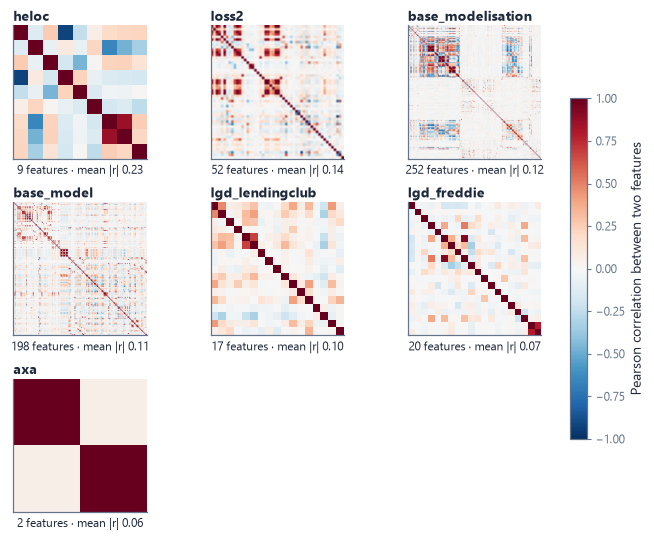

In [11]:
for _p in range(1, data_plots.correlation_pages(lgd) + 1):
    FIGS.save(data_plots.plot_feature_correlations(lgd, page=_p), f"feature_correlations_lgd_p{_p}",
        caption="Pearson correlation matrices between the features of each LGD dataset on a random 5,000-row sample with constant columns removed, colour scale from -1 to 1, datasets ordered by mean absolute correlation, which is given under each panel.");

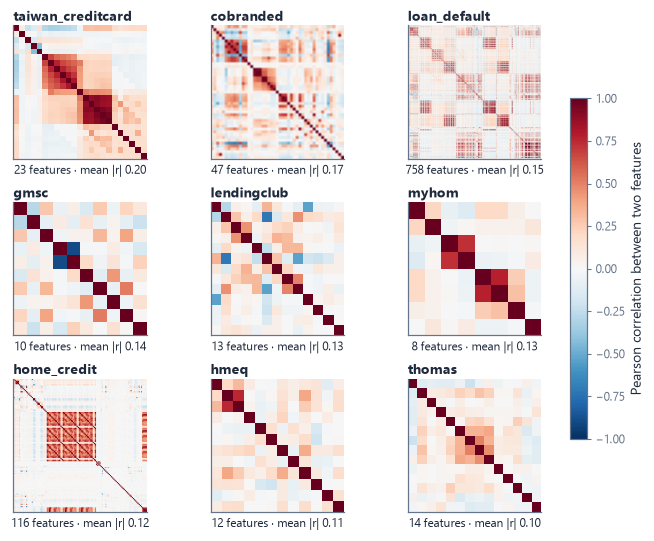

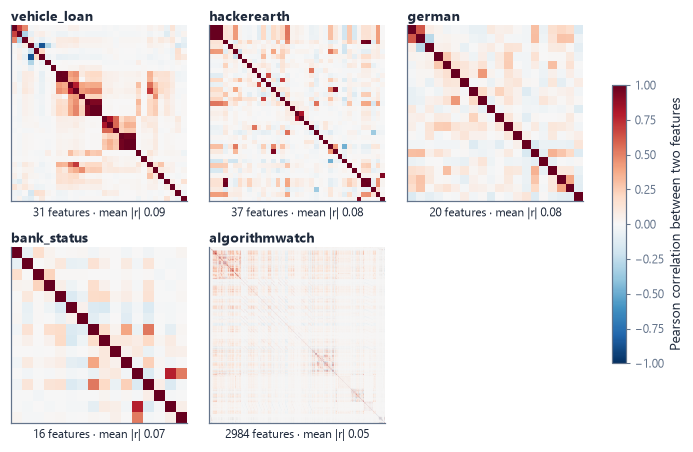

In [12]:
for _p in range(1, data_plots.correlation_pages(pd_) + 1):
    FIGS.save(data_plots.plot_feature_correlations(pd_, page=_p), f"feature_correlations_pd_p{_p}",
        caption="Pearson correlation matrices between the features of each PD dataset on a random 5,000-row sample with constant columns removed, colour scale from -1 to 1, datasets ordered by mean absolute correlation, which is given under each panel.");

## C · Can the scores be trusted?

A benchmark is only as good as its datasets. One screen, which has already pointed at something.

### C1 · Does any single column give the answer away?

**What it shows.** For every dataset, its single most target-correlated feature: the absolute correlation as a bar, the feature's name beside it, a red outline above the 0.9 flag threshold. The three tables below it list the top three features per dataset, and the flagged ones.

**Why it matters.** A column that encodes the outcome inflates every model's score and makes the comparison between priors meaningless. The screen exists because `lgd_lendingclub` reaches an R² of 0.71–0.76 in evaluation, far above anything published for LGD.

**What it says.** Nothing crosses 0.9. But two LGD datasets carry most of their signal in one column: `lgd_lendingclub`'s `months_since_origination` correlates 0.75 with the loss — on its own that explains 57 % of the variance, most of the dataset's R² — and `loss2`'s `REO_Appraisal_Amount` 0.71. Whether that is leakage depends on when each column is measured, which the files do not record; read those two datasets' scores with it in mind. A one-column screen cannot see leakage spread over several columns.

In [13]:
leak_lgd = data_plots.leakage_check(lgd, "lgd")
leak_pd = data_plots.leakage_check(pd_, "pd")
LEAKS = pd.concat([leak_lgd.assign(task="lgd"), leak_pd.assign(task="pd")])

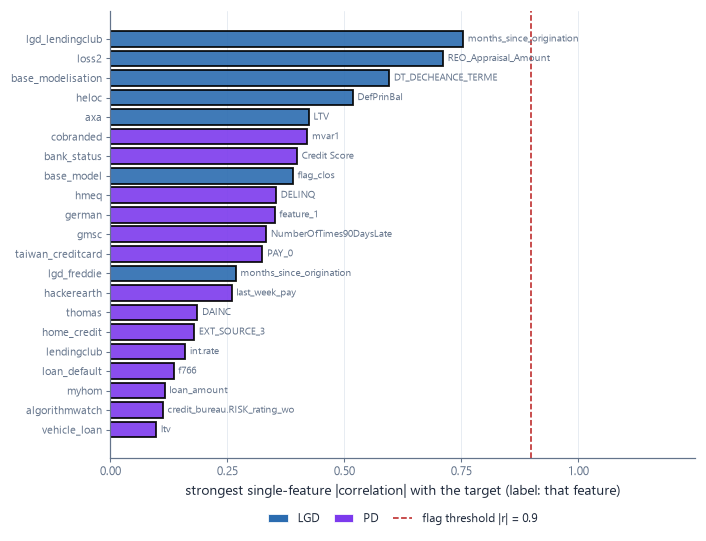

In [14]:
FIGS.save(data_plots.plot_leakage_screen(LEAKS), "leakage_screen",
    caption="Largest absolute Pearson correlation between a single feature and the target per dataset, all 21 evaluation datasets, as horizontal bars labelled with that feature and coloured by task; the dashed line marks the 0.9 flag threshold.");

In [15]:
leak_lgd.head(12)

,dataset,feature,|corr with target|,suspicious
0,0007.lgd_lendingclub,months_since_origination,0.754,False
1,0002.loss2,REO_Appraisal_Amount,0.711,False
2,0005.base_modelisation,DT_DECHEANCE_TERME,0.596,False
3,0005.base_modelisation,topbaloispur_cor,0.589,False
4,0001.heloc,DefPrinBal,0.518,False
5,0002.loss2,amount_funded,0.490,False
6,0001.heloc,Utilization,0.489,False
7,0002.loss2,Original_UPB,0.488,False
8,0003.axa,LTV,0.424,False
9,0004.base_model,flag_clos,0.390,False


In [16]:
leak_pd.head(12)

,dataset,feature,|corr with target|,suspicious
0,0007.cobranded,mvar1,0.421,False
1,0009.bank_status,Credit Score,0.399,False
2,0007.cobranded,mvar8,0.369,False
3,0007.cobranded,mvar6,0.358,False
4,0013.hmeq,DELINQ,0.354,False
5,0008.german,feature_1,0.351,False
6,0001.gmsc,NumberOfTimes90DaysLate,0.333,False
7,0002.taiwan_creditcard,PAY_0,0.325,False
8,0001.gmsc,NumberOfTime30-59DaysPastDueNotWorse,0.287,False
9,0001.gmsc,RevolvingUtilizationOfUnsecuredLines,0.278,False


In [17]:
LEAKS[LEAKS["suspicious"]]

,dataset,feature,|corr with target|,suspicious,task


## Summary

The datasets in text, PD first and then LGD — sizes, feature types, missing values and the target —
then the leakage screen and the feature dependence. Printed last, so `output/All_Results.md` carries
the numbers, followed by the `tfm-library` sources cited (pin `e5ce016`) and the list of figures.

In [18]:
print(summaries.data_summary({"pd": pd_, "lgd": lgd}, leakage=LEAKS))
print()
print(literature.references_md(["tanna_paradox", "hc_base_rate", "tabicl_impute", "purucker_highcard", "purucker_missing", "oprior_scope"]))
print()
print(FIGS.summary())


EVALUATION DATASET SUMMARY
21 datasets loaded: PD=14, LGD=7

--- PD ------------------------------------------------------------------------
rows      1000 to 5.324e+05 (median 9e+04)
features  8 to 2986 (median 21.5)
categorical share  0.0% to 65.0% (median 4.2%)
missing cells      0.0% to 22.7% (median 0.7%)  —  6/14 have NONE left (pre-imputed upstream)

base rate          6.7% to 40.0% (median 22.4%)
  gmsc                       6.7%   (1 default per 14 non-defaults)
  home_credit                8.1%   (1 default per 11 non-defaults)
  loan_default               9.3%   (1 default per 9.8 non-defaults)
  lendingclub               16.0%   (1 default per 5.2 non-defaults)
  hmeq                      19.9%   (1 default per 4 non-defaults)
  vehicle_loan              21.7%   (1 default per 3.6 non-defaults)
  taiwan_creditcard         22.1%   (1 default per 3.5 non-defaults)
  bank_status               22.6%   (1 default per 3.4 non-defaults)
  hackerearth               23.6%   (1 defa